<a href="https://colab.research.google.com/github/xinliwvu/MTF/blob/main/mtf_vs_lmsrr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MTF-ViT vs LMSRR: Class-Incremental Learning on CIFAR-100

Following **Table 2** of the LMSRR paper (NeurIPS 2025):
CIFAR-100, 10 tasks × 10 classes, buffer=500, 1 epoch/task.

| | LMSRR | MTF-ViT |
|---|---|---|
| Backbones | 2 ViTs, last 3 layers unfrozen | 1 ViT, fully frozen |
| Memory buffer | Yes (500 samples) | No |
| Feature fusion | MSIDF (multi-scale Conv1d) | None |
| Regularization | MLRO + ARO (Gumbel-Softmax) | None (structural decoupling) |
| Classifier | Single shared 768→100 | Per-expert ExpertHead |
| Task boundaries | Required | Not required |


In [ ]:
# ============================================================
# Cell 1: Setup + CIFAR-100 CIL Data (10 tasks x 10 classes)
# ============================================================
!pip install timm -q

import copy, time, random
from collections import deque
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms.functional import InterpolationMode
import timm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
train_tf = transforms.Compose([
    transforms.Resize(224, interpolation=InterpolationMode.BICUBIC),
    transforms.RandomCrop(224, padding=16), transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
test_tf = transforms.Compose([
    transforms.Resize(224, interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

train_ds = torchvision.datasets.CIFAR100('./data', train=True,  download=True, transform=train_tf)
test_ds  = torchvision.datasets.CIFAR100('./data', train=False, download=True, transform=test_tf)
# Also need un-augmented images for LMSRR buffer
train_ds_raw = torchvision.datasets.CIFAR100('./data', train=True,  download=False, transform=test_tf)

N_TASKS, N_CLASSES, CLS_PER_TASK = 10, 100, 10
BATCH, BUFFER_SIZE = 32, 500

rng = np.random.RandomState(42)
class_order = rng.permutation(N_CLASSES).tolist()
train_targets = np.array(train_ds.targets)
test_targets  = np.array(test_ds.targets)
task_classes = [class_order[t*CLS_PER_TASK:(t+1)*CLS_PER_TASK] for t in range(N_TASKS)]

train_loaders, test_loaders = [], []
train_raw_loaders = []
for t in range(N_TASKS):
    cls = task_classes[t]
    tr_idx = [i for i, y in enumerate(train_targets) if y in cls]
    te_idx = [i for i, y in enumerate(test_targets)  if y in cls]
    train_loaders.append(DataLoader(Subset(train_ds, tr_idx), batch_size=BATCH, shuffle=True, num_workers=2))
    train_raw_loaders.append(DataLoader(Subset(train_ds_raw, tr_idx), batch_size=BATCH, shuffle=True, num_workers=2))
    test_loaders.append(DataLoader(Subset(test_ds, te_idx), batch_size=64, shuffle=False, num_workers=2))

print(f'{N_TASKS} tasks, {CLS_PER_TASK} classes/task, class order: {class_order[:20]}...')


Device: cuda
10 tasks, 10 classes/task, class order: [83, 53, 70, 45, 44, 39, 22, 80, 10, 0, 18, 30, 73, 33, 90, 4, 76, 77, 12, 31]...


In [ ]:
# ============================================================
# Cell 2: Shared Evaluation
# ============================================================

def evaluate_cil(model_fn, test_loaders_so_far, classes_so_far):
    """Class-incremental evaluation: predict among ALL classes seen so far."""
    correct, total = 0, 0
    mask = torch.full((N_CLASSES,), -1e9, device=DEVICE)
    for c in classes_so_far: mask[c] = 0
    for loader in test_loaders_so_far:
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            with torch.no_grad():
                logits = model_fn(x)
                pred = (logits + mask).argmax(dim=1)
            correct += (pred == y).sum().item()
            total += len(y)
    return correct / total if total > 0 else 0.0

class ReplayBuffer:
    """Simple reservoir-sampling buffer storing (image, logits) pairs."""
    def __init__(self, max_size):
        self.max_size = max_size
        self.images = []; self.logits = []
        self.n_seen = 0

    def add(self, imgs, lgts):
        for i in range(len(imgs)):
            self.n_seen += 1
            if len(self.images) < self.max_size:
                self.images.append(imgs[i].cpu())
                self.logits.append(lgts[i].cpu())
            else:
                j = random.randint(0, self.n_seen - 1)
                if j < self.max_size:
                    self.images[j] = imgs[i].cpu()
                    self.logits[j] = lgts[i].cpu()

    def sample(self, n):
        idx = random.sample(range(len(self.images)), min(n, len(self.images)))
        imgs = torch.stack([self.images[i] for i in idx]).to(DEVICE)
        lgts = torch.stack([self.logits[i] for i in idx]).to(DEVICE)
        return imgs, lgts

    def __len__(self): return len(self.images)

print('Evaluation + Buffer ready.')


Evaluation + Buffer ready.


## LMSRR (NeurIPS 2025)

In [ ]:
# ============================================================
# Cell 3: LMSRR -- Learning Multi-Source and Robust Representations
# ============================================================
# From source code: 2 ViTs + MSIDF (Conv1d fusion) + MLRO + ARO (Gumbel-Softmax)
# Uses timm ViTs instead of HuggingFace (same architecture, simpler API)

class GumbelSelector(nn.Module):
    """ARO: Adaptive Regularization Optimization via Gumbel-Softmax."""
    def __init__(self, n_layers, tau=0.1):
        super().__init__()
        self.tau = tau
        self.weights = nn.ParameterList([nn.Parameter(torch.randn(2)) for _ in range(n_layers)])

    def forward(self, layer_idx):
        logits = self.weights[layer_idx]
        gumbel = -torch.log(-torch.log(torch.rand_like(logits) + 1e-20) + 1e-20)
        y = F.softmax((logits + gumbel) / self.tau, dim=-1)
        return y[0]  # probability of "activate regularization"

class MSIDF(nn.Module):
    """Multi-Scale Interaction and Dynamic Fusion."""
    def __init__(self, n_sources):
        super().__init__()
        self.conv3 = nn.Conv1d(n_sources, 1, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(n_sources, 1, kernel_size=5, padding=2)
        self.fusion_w = nn.Parameter(torch.ones(2))
        nn.init.xavier_uniform_(self.conv3.weight)
        nn.init.xavier_uniform_(self.conv5.weight)

    def forward(self, stacked):  # [B, n_sources, 768]
        b1 = self.conv3(stacked)  # [B, 1, 768]
        b2 = self.conv5(stacked)  # [B, 1, 768]
        w = F.softmax(self.fusion_w, dim=0)
        return (w[0]*b1 + w[1]*b2).squeeze(1)  # [B, 768]

class LMSRRModel(nn.Module):
    def __init__(self, n_classes=100, n_unfrozen=3):
        super().__init__()
        self.n_unfrozen = n_unfrozen
        # Two ViT backbones (different pretraining)
        self.vit1 = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
        # Two ViTs with same pretrained weights (diverge during training via MSIDF)
        # Original uses HF google/vit-base-patch16-224 + google/vit-base-patch16-224-in21k
        self.vit2 = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
        for vit in [self.vit1, self.vit2]:
            for p in vit.parameters(): p.requires_grad = False
            for block in vit.blocks[-n_unfrozen:]:
                for p in block.parameters(): p.requires_grad = True
        # MSIDF
        self.msidf = MSIDF(2)
        # ARO selectors (one per ViT, each with n_unfrozen layers)
        self.selectors = nn.ModuleList([GumbelSelector(n_unfrozen) for _ in range(2)])
        # Single shared classifier
        self.classifier = nn.Linear(768, n_classes)

    def extract_with_intermediates(self, vit, x):
        """Forward through ViT, return CLS token + last n_unfrozen hidden states."""
        x_proc = x
        if x_proc.shape[-1] != 224:
            x_proc = F.interpolate(x_proc, size=224, mode='bicubic', align_corners=False)
        feats = vit.patch_embed(x_proc)
        feats = torch.cat((vit.cls_token.expand(feats.shape[0],-1,-1), feats), dim=1)
        feats = feats + vit.pos_embed
        intermediates = []
        for i, block in enumerate(vit.blocks):
            feats = block(feats)
            if i >= len(vit.blocks) - self.n_unfrozen:
                intermediates.append(feats[:, 0, :])  # CLS token at each layer
        cls = vit.norm(feats)[:, 0, :]
        return cls, intermediates

    def forward(self, x):
        cls1, _ = self.extract_with_intermediates(self.vit1, x)
        cls2, _ = self.extract_with_intermediates(self.vit2, x)
        stacked = torch.stack([cls1, cls2], dim=1)  # [B, 2, 768]
        fused = self.msidf(stacked)
        return self.classifier(fused)

    def forward_with_intermediates(self, x):
        cls1, inter1 = self.extract_with_intermediates(self.vit1, x)
        cls2, inter2 = self.extract_with_intermediates(self.vit2, x)
        stacked = torch.stack([cls1, cls2], dim=1)
        fused = self.msidf(stacked)
        return self.classifier(fused), [inter1, inter2]


def run_lmsrr(train_loaders, train_raw_loaders, test_loaders, task_classes,
              lr=0.03, alpha=0.3, beta=0.2, epochs=1):
    print('\n' + '='*60)
    print('LMSRR (NeurIPS 2025) -- CIL on CIFAR-100')
    print('='*60)
    model = LMSRRModel(N_CLASSES).to(DEVICE)
    buf = ReplayBuffer(BUFFER_SIZE)
    acc_matrix = np.zeros((N_TASKS, N_TASKS))
    old_model = None

    for t in range(N_TASKS):
        classes_so_far = [c for tt in range(t+1) for c in task_classes[tt]]
        print(f'\nTask {t+1}/{N_TASKS} (classes {task_classes[t]})')

        # begin_task: snapshot + optimizer
        old_model = copy.deepcopy(model)
        for p in old_model.parameters(): p.requires_grad = False
        opt = torch.optim.SGD([p for p in model.parameters() if p.requires_grad],
                              lr=lr, momentum=0.9)

        for ep in range(epochs):
            model.train()
            ep_loss = 0; n = 0
            raw_iter = iter(train_raw_loaders[t])
            for x, y in train_loaders[t]:
                x, y = x.to(DEVICE), y.to(DEVICE)
                opt.zero_grad()
                logits, intermediates = model.forward_with_intermediates(x)
                loss = F.cross_entropy(logits, y)

                # MLRO + ARO: regularize intermediate features
                if t > 0:
                    with torch.no_grad():
                        _, old_inter = old_model.forward_with_intermediates(x)
                    reg = 0.0; reg_count = 0.0
                    for v, (new_ints, old_ints, sel) in enumerate(
                            zip(intermediates, old_inter, model.selectors)):
                        for l_idx, (nf, of) in enumerate(zip(new_ints, old_ints)):
                            w = sel(l_idx)
                            reg += w * F.mse_loss(nf, of.detach())
                            reg_count += w
                    if reg_count > 0: reg /= reg_count
                    loss += alpha * reg

                # Buffer replay (logit distillation)
                if len(buf) > 0:
                    buf_imgs, buf_lgts = buf.sample(BATCH)
                    buf_out = model(buf_imgs)
                    loss += beta * F.mse_loss(buf_out, buf_lgts)

                loss.backward()
                torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 1.0)
                opt.step()
                ep_loss += F.cross_entropy(logits.detach(), y).item() * len(x); n += len(x)

                # Add to buffer (use raw/un-augmented images)
                try:
                    raw_x, raw_y = next(raw_iter)
                except StopIteration:
                    raw_iter = iter(train_raw_loaders[t])
                    raw_x, raw_y = next(raw_iter)
                raw_x = raw_x.to(DEVICE)
                with torch.no_grad():
                    raw_lgts = model(raw_x)
                buf.add(raw_x, raw_lgts)

            print(f'    Epoch {ep+1}/{epochs}, CE={ep_loss/n:.3f}, buf={len(buf)}')

        # Evaluate
        for i in range(t+1):
            acc_matrix[i][t] = evaluate_cil(lambda x: model(x),
                                             [test_loaders[i]], classes_so_far)
        avg = acc_matrix[:t+1, t].mean()
        print(f'  Avg acc: {avg:.3f}')

    return acc_matrix

print('LMSRR ready.')


LMSRR ready.


## MTF-ViT (Ours)

In [ ]:
# ============================================================
# Cell 4: MTF-ViT -- Autonomous Expert Allocation
# ============================================================
# Single frozen ViT, no buffer, no task boundaries.

class LossAlarm:
    def __init__(self, w, a):
        self.window = deque(maxlen=w)
        self.ema=0.; self.alpha=a; self.baseline=0.; self.n=0
    def update(self, v):
        self.window.append(v); self.n+=1
        self.ema=(1-self.alpha)*self.ema+self.alpha*v
        if self.n<=5: self.baseline=self.ema
        else: self.baseline=0.95*self.baseline+0.05*self.ema
    def mean(self): return float(np.mean(self.window)) if self.window else 0.
    def reset(self): self.window.clear(); self.ema=0; self.baseline=0; self.n=0

class ExpertHead(nn.Module):
    def __init__(self, d=768, h=256, c=100):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,h), nn.ReLU(), nn.Dropout(0.1), nn.Linear(h,c))
    def forward(self, x): return self.net(x)

class MTFViT(nn.Module):
    def __init__(self, n_classes=100):
        super().__init__()
        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
        for p in self.vit.parameters(): p.requires_grad = False
        self.feat_dim = 768; self.n_classes = n_classes
        self.active = ExpertHead(self.feat_dim, 256, n_classes)
        self.pool = []; self.centroids = []; self.counts = []
        self.fast=LossAlarm(5,.4); self.med=LossAlarm(10,.15); self.slow=LossAlarm(20,.05)
        self.sigs=[self.fast,self.med,self.slow]
        self.n_ctx=0; self.warmup=15; self.spike=0.5; self.c_thresh=3.0
        self.events=[]; self._step=0

    def extract(self, x):
        with torch.no_grad(): return self.vit(x)

    def alarm(self, lv):
        for s in self.sigs: s.update(lv)
        self.n_ctx+=1
        if self.n_ctx<=self.warmup: return False
        return ((self.med.baseline<1. and self.fast.mean()>self.med.baseline+self.spike) or
                (self.med.baseline>0.01 and self.fast.mean()>2.*self.med.baseline
                 and self.med.mean()>1.5*self.slow.mean()))

    def update_centroid(self, f):
        bc=f.mean(0).detach().cpu().numpy()
        if not self.centroids:
            self.centroids.append(bc.copy()); self.counts.append(1)
        else:
            i=len(self.centroids)-1; self.counts[i]+=1
            self.centroids[i]+=(bc-self.centroids[i])/self.counts[i]

    def snapshot_alloc(self):
        snap=copy.deepcopy(self.active)
        for p in snap.parameters(): p.requires_grad=False
        self.pool.append(snap)
        self.active=ExpertHead(self.feat_dim,256,self.n_classes).to(DEVICE)
        for s in self.sigs: s.reset()
        self.n_ctx=0
        self.centroids.append(np.zeros(self.feat_dim)); self.counts.append(0)
        self.events.append((self._step,'alloc',len(self.pool)))

    def recog_or_alloc(self, f):
        bc=f.mean(0).detach().cpu().numpy()
        bi,bd=-1,float('inf')
        for i,c in enumerate(self.centroids[:-1]):
            if self.counts[i]==0: continue
            d=np.linalg.norm(bc-c)
            if d<bd: bd=d; bi=i
        if bd<self.c_thresh and bi>=0:
            self.events.append((self._step,'recog',bi))
            self.active=copy.deepcopy(self.pool[bi]).to(DEVICE)
            for p in self.active.parameters(): p.requires_grad=True
            for s in self.sigs: s.reset(); self.n_ctx=0
        else: self.snapshot_alloc()

    def route_predict(self, x):
        with torch.no_grad():
            f=self.vit(x); bc=f.mean(0).cpu().numpy()
            all_e=self.pool+[self.active]; best=len(all_e)-1; bd=float('inf')
            for i,c in enumerate(self.centroids):
                if i<len(self.counts) and self.counts[i]==0: continue
                d=np.linalg.norm(bc-c)
                if d<bd: bd=d; best=i
            return all_e[min(best,len(all_e)-1)](f)


def run_mtf(train_loaders, test_loaders, task_classes, epochs=1, lr=0.005):
    print('\n' + '='*60)
    print('MTF-ViT (Ours) -- CIL on CIFAR-100 (no task boundaries)')
    print('='*60)
    model = MTFViT(N_CLASSES).to(DEVICE)
    opt = torch.optim.Adam(model.active.parameters(), lr=lr)
    acc_matrix = np.zeros((N_TASKS, N_TASKS))

    for t in range(N_TASKS):
        classes_so_far = [c for tt in range(t+1) for c in task_classes[tt]]
        print(f'\nTask {t+1}/{N_TASKS} (MTF: no boundary)')
        for ep in range(epochs):
            ep_loss=0; n=0
            for x, y in train_loaders[t]:
                x,y=x.to(DEVICE),y.to(DEVICE)
                f=model.extract(x)
                # E
                model.active.eval()
                with torch.no_grad(): pl=F.cross_entropy(model.active(f),y).item()
                # D
                if model.alarm(pl):
                    model.recog_or_alloc(f)
                    opt=torch.optim.Adam(model.active.parameters(),lr=lr)
                # C
                model.active.train()
                logits=model.active(f)
                loss=F.cross_entropy(logits,y)
                opt.zero_grad(); loss.backward(); opt.step()
                model.update_centroid(f); model._step+=1
                ep_loss+=loss.item()*len(x); n+=len(x)
            na=sum(1 for _,e,_ in model.events if e=='alloc')
            print(f'    Epoch {ep+1}/{epochs}, CE={ep_loss/n:.3f}, experts={len(model.pool)+1}')

        for i in range(t+1):
            acc_matrix[i][t]=evaluate_cil(model.route_predict,[test_loaders[i]],classes_so_far)
        print(f'  Avg acc: {acc_matrix[:t+1,t].mean():.3f}')
    return acc_matrix

print('MTF-ViT ready.')


MTF-ViT ready.


## Run Experiments

In [5]:
t0 = time.time()
A_lmsrr = run_lmsrr(train_loaders, train_raw_loaders, test_loaders, task_classes,
                     lr=0.03, alpha=0.3, beta=0.2, epochs=1)
print(f'\nTime: {time.time()-t0:.0f}s')



LMSRR (NeurIPS 2025) -- CIL on CIFAR-100


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



Task 1/10 (classes [83, 53, 70, 45, 44, 39, 22, 80, 10, 0])
    Epoch 1/1, CE=0.414, buf=500
  Avg acc: 0.947

Task 2/10 (classes [18, 30, 73, 33, 90, 4, 76, 77, 12, 31])
    Epoch 1/1, CE=0.598, buf=500
  Avg acc: 0.887

Task 3/10 (classes [55, 88, 26, 42, 69, 15, 40, 96, 9, 72])
    Epoch 1/1, CE=0.709, buf=500
  Avg acc: 0.813

Task 4/10 (classes [11, 47, 85, 28, 93, 5, 66, 65, 35, 16])
    Epoch 1/1, CE=0.673, buf=500
  Avg acc: 0.822

Task 5/10 (classes [49, 34, 7, 95, 27, 19, 81, 25, 62, 13])
    Epoch 1/1, CE=0.575, buf=500
  Avg acc: 0.758

Task 6/10 (classes [24, 3, 17, 38, 8, 78, 6, 64, 36, 89])
    Epoch 1/1, CE=0.574, buf=500
  Avg acc: 0.784

Task 7/10 (classes [56, 99, 54, 43, 50, 67, 46, 68, 61, 97])
    Epoch 1/1, CE=0.577, buf=500
  Avg acc: 0.742

Task 8/10 (classes [79, 41, 58, 48, 98, 57, 75, 32, 94, 59])
    Epoch 1/1, CE=0.581, buf=500
  Avg acc: 0.750

Task 9/10 (classes [63, 84, 37, 29, 1, 52, 21, 2, 23, 87])
    Epoch 1/1, CE=0.563, buf=500
  Avg acc: 0.744

T

In [6]:
t0 = time.time()
A_mtf = run_mtf(train_loaders, test_loaders, task_classes, epochs=1, lr=0.005)
print(f'\nTime: {time.time()-t0:.0f}s')



MTF-ViT (Ours) -- CIL on CIFAR-100 (no task boundaries)

Task 1/10 (MTF: no boundary)
    Epoch 1/1, CE=0.398, experts=1
  Avg acc: 0.879

Task 2/10 (MTF: no boundary)
    Epoch 1/1, CE=0.437, experts=2
  Avg acc: 0.889

Task 3/10 (MTF: no boundary)
    Epoch 1/1, CE=0.448, experts=3
  Avg acc: 0.884

Task 4/10 (MTF: no boundary)
    Epoch 1/1, CE=0.412, experts=4
  Avg acc: 0.872

Task 5/10 (MTF: no boundary)
    Epoch 1/1, CE=0.340, experts=5
  Avg acc: 0.885

Task 6/10 (MTF: no boundary)
    Epoch 1/1, CE=0.315, experts=6
  Avg acc: 0.892

Task 7/10 (MTF: no boundary)
    Epoch 1/1, CE=0.279, experts=7
  Avg acc: 0.901

Task 8/10 (MTF: no boundary)
    Epoch 1/1, CE=0.295, experts=8
  Avg acc: 0.907

Task 9/10 (MTF: no boundary)
    Epoch 1/1, CE=0.303, experts=9
  Avg acc: 0.910

Task 10/10 (MTF: no boundary)
    Epoch 1/1, CE=0.335, experts=10
  Avg acc: 0.912

Time: 1284s


## Results

CIFAR-100 CLASS-INCREMENTAL (Table 2 format)
10 tasks x 10 classes, 1 epoch/task
Method        Average     Last      BWT  Buffer Task IDs
----------------------------------------------------------
LMSRR           71.8%    95.6%   -0.261     500      Yes
MTF-ViT         91.2%    93.4%    0.002       0       No


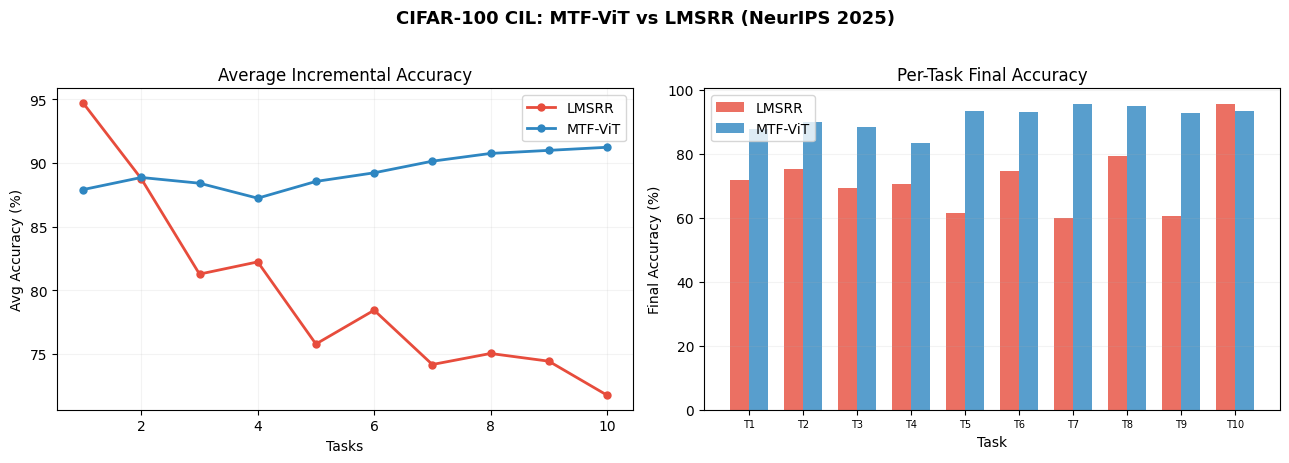

In [7]:
# ============================================================
# Cell 7: Compare -- Table 2 format
# ============================================================
import matplotlib.pyplot as plt

def metrics(A):
    T=A.shape[0]
    avg=A[:,-1].mean(); last=A[-1,-1]
    bwt=sum(A[i,-1]-A[i,i] for i in range(T-1))/(T-1)
    return avg, last, bwt

avg_l, last_l, bwt_l = metrics(A_lmsrr)
avg_m, last_m, bwt_m = metrics(A_mtf)

print('='*60)
print('CIFAR-100 CLASS-INCREMENTAL (Table 2 format)')
print(f'{N_TASKS} tasks x {CLS_PER_TASK} classes, 1 epoch/task')
print('='*60)
print(f'{"Method":12s} {"Average":>8s} {"Last":>8s} {"BWT":>8s}  {"Buffer":>6s} {"Task IDs":>8s}')
print('-'*58)
print(f'{"LMSRR":12s} {avg_l:8.1%} {last_l:8.1%} {bwt_l:8.3f}  {"500":>6s} {"Yes":>8s}')
print(f'{"MTF-ViT":12s} {avg_m:8.1%} {last_m:8.1%} {bwt_m:8.3f}  {"0":>6s} {"No":>8s}')

# Incremental accuracy plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = {'LMSRR':'#E74C3C', 'MTF-ViT':'#2E86C1'}

ax = axes[0]
for name, A in [('LMSRR', A_lmsrr), ('MTF-ViT', A_mtf)]:
    avg = [A[:t+1,t].mean()*100 for t in range(N_TASKS)]
    ax.plot(range(1,N_TASKS+1), avg, '-o', color=colors[name], lw=2, ms=5, label=name)
ax.set_xlabel('Tasks'); ax.set_ylabel('Avg Accuracy (%)')
ax.set_title('Average Incremental Accuracy'); ax.legend(); ax.grid(True, alpha=.15)

ax = axes[1]
x = np.arange(N_TASKS); w = 0.35
for i,(name,A) in enumerate([('LMSRR',A_lmsrr),('MTF-ViT',A_mtf)]):
    ax.bar(x+(i-.5)*w, [A[t,-1]*100 for t in range(N_TASKS)], w,
           color=colors[name], label=name, alpha=0.8)
ax.set_xlabel('Task'); ax.set_ylabel('Final Accuracy (%)')
ax.set_title('Per-Task Final Accuracy')
ax.set_xticks(x); ax.set_xticklabels([f'T{t+1}' for t in range(N_TASKS)], fontsize=7)
ax.legend(); ax.grid(True, alpha=.15, axis='y')

fig.suptitle('CIFAR-100 CIL: MTF-ViT vs LMSRR (NeurIPS 2025)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mtf_vs_lmsrr.png', dpi=150, bbox_inches='tight')
plt.show()
